**Predicción de Calidad del Vino (Core)**

Descripción del Dataset: Este conjunto de datos contiene información sobre distintas características físico-químicas de muestras de vino tinto y su calidad asociada. Las características incluyen acidez fija, acidez volátil, ácido cítrico, azúcar residual, cloruros, dióxido de azufre libre, dióxido de azufre total, densidad, pH, sulfatos y alcohol. La calidad del vino está clasificada en una escala del 0 al 10.

**1. Carga y Exploración de Datos:**

1.1. Cargar el dataset y revisar su estructura básica.

1.2. Describir las variables y su distribución.

1.3. Identificar y tratar valores nulos y outliers.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, roc_curve, classification_report,
                              confusion_matrix, ConfusionMatrixDisplay)

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)

In [4]:
# 1.1. Cargar el dataset y revisar su estructura básica.
df = pd.read_csv('/content/WineQT.csv')
print(f'Dataset cargado — shape: {df.shape}')
print(f'Columnas ({len(df.columns)}): {list(df.columns)}')

Dataset cargado — shape: (1143, 13)
Columnas (13): ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality', 'Id']


In [5]:
# 1.2. Descripción de las variables y su distribución.
display(df.head())
display(df.tail())
df.info()
display(df.describe())

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
1138,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6,1592
1139,6.8,0.620,0.08,1.9,0.068,28.0,38.0,0.99651,3.42,0.82,9.5,6,1593
1140,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5,1594
1141,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6,1595
1142,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5,1597


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
count,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000
mean,8.311111,0.531339,0.268364,2.532152,0.086933,15.615486,45.914698,0.996730,3.311015,0.657708,10.442111,5.657043,804.969379
std,1.747595,0.179633,0.196686,1.355917,0.047267,10.250486,32.782130,0.001925,0.156664,0.170399,1.082196,0.805824,463.997116
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000,0.000000
25%,7.100000,0.392500,0.090000,1.900000,0.070000,7.000000,21.000000,0.995570,3.205000,0.550000,9.500000,5.000000,411.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,37.000000,0.996680,3.310000,0.620000,10.200000,6.000000,794.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,61.000000,0.997845,3.400000,0.730000,11.100000,6.000000,1209.500000
max,15.900000,1.580000,1.000000,15.500000,0.611000,68.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000,1597.000000


In [7]:
print(df['quality'].value_counts().sort_index())

quality
3      6
4     33
5    483
6    462
7    143
8     16
Name: count, dtype: int64


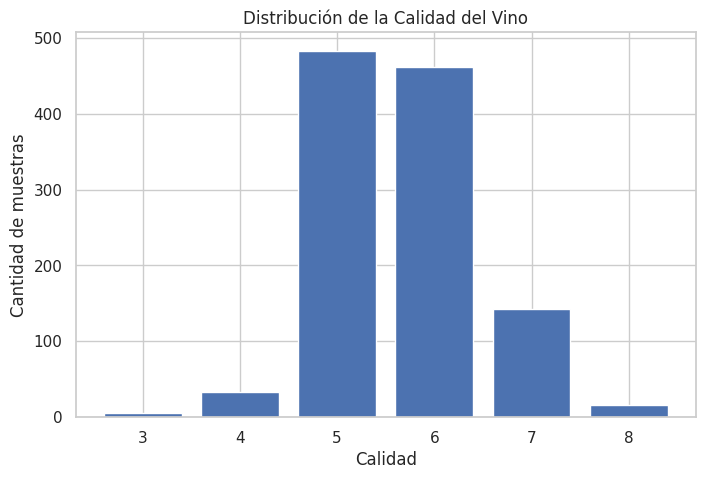

In [8]:
# Gráfico de barras de la calidad del vino

calidad = df['quality'].value_counts().sort_index()

plt.figure(figsize=(8,5))
plt.bar(calidad.index, calidad.values)

plt.title('Distribución de la Calidad del Vino')
plt.xlabel('Calidad')
plt.ylabel('Cantidad de muestras')

plt.show()

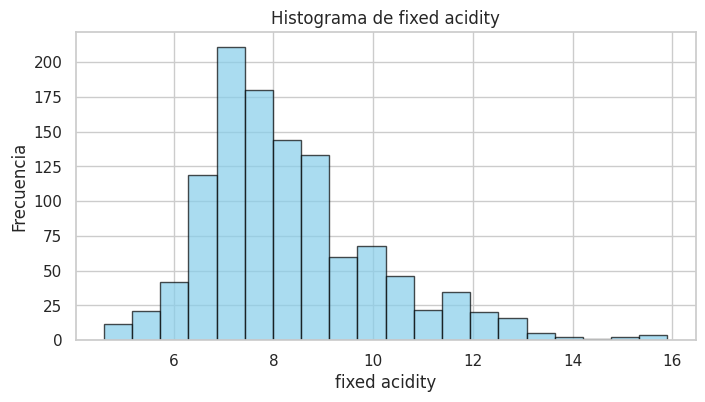

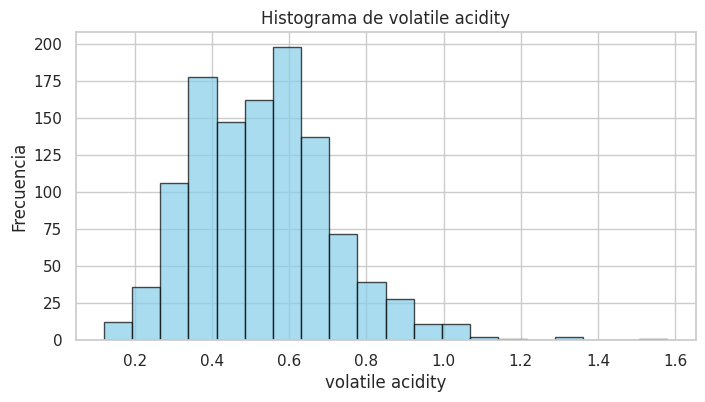

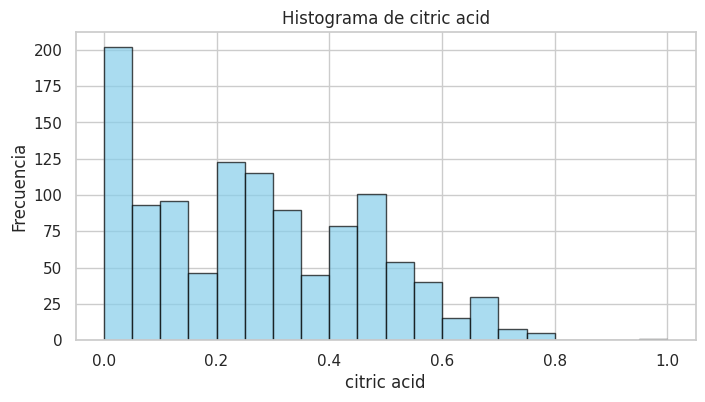

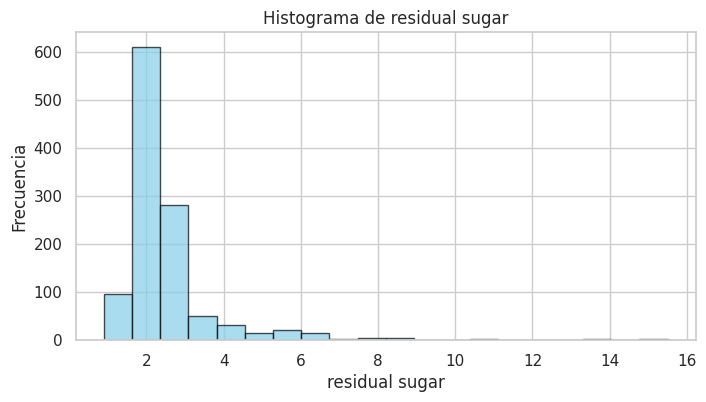

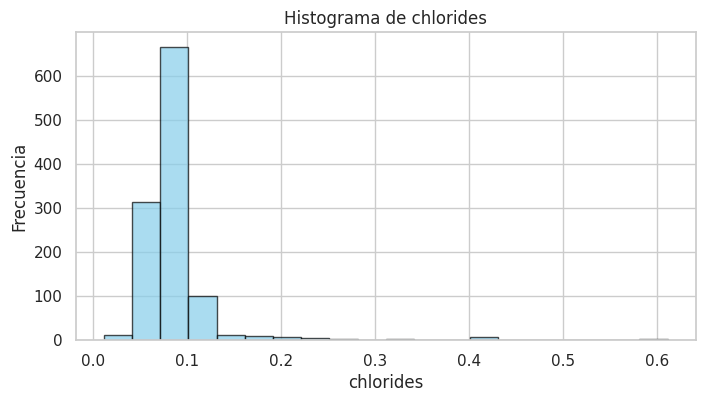

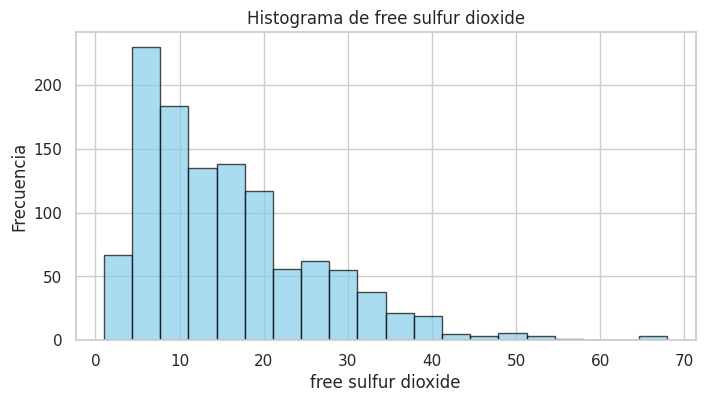

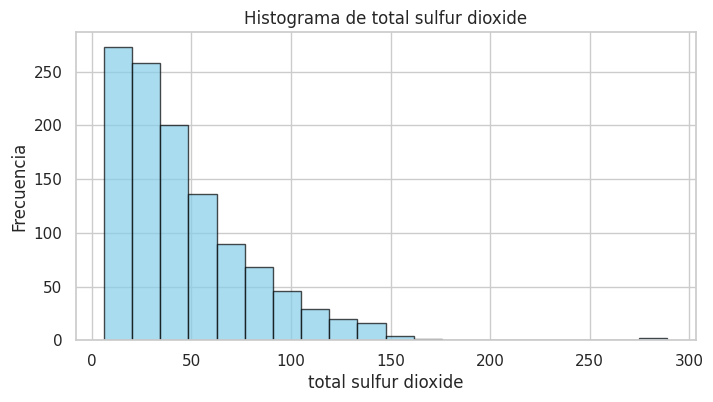

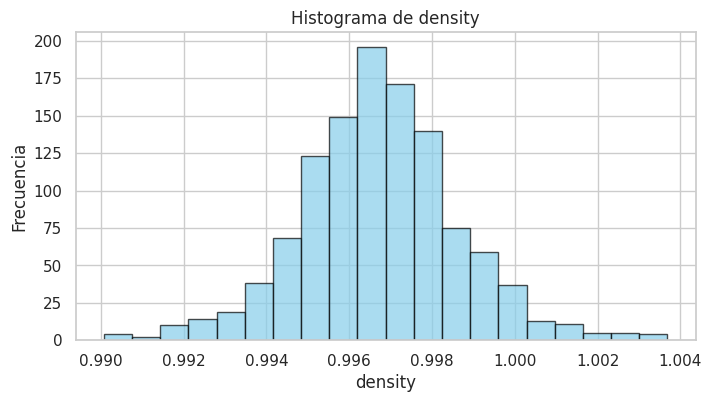

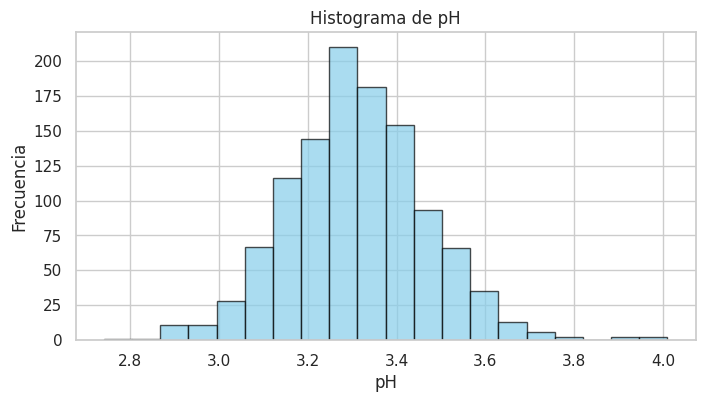

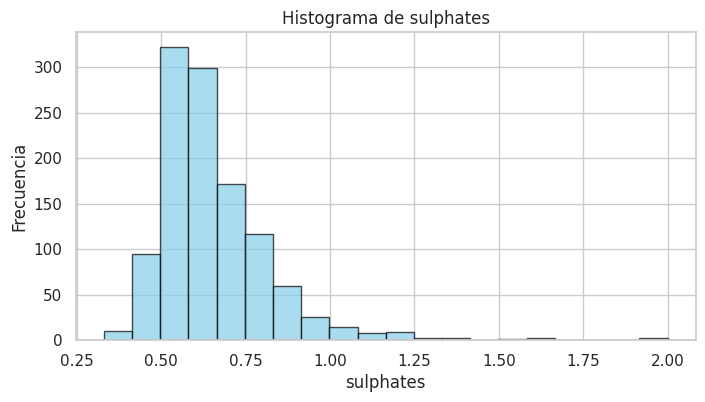

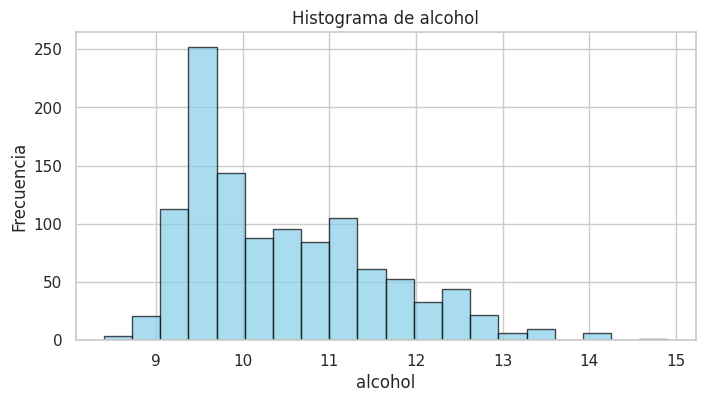

In [9]:
# Histogramas de variables numéricas

variables = [
    'fixed acidity',
    'volatile acidity',
    'citric acid',
    'residual sugar',
    'chlorides',
    'free sulfur dioxide',
    'total sulfur dioxide',
    'density',
    'pH',
    'sulphates',
    'alcohol'
]

for col in variables:

    plt.figure(figsize=(8,4))

    plt.hist(
        df[col],
        bins=20,
        color='skyblue',
        edgecolor='black',
        alpha=0.7
    )

    plt.title(f'Histograma de {col}')
    plt.xlabel(col)
    plt.ylabel('Frecuencia')
    plt.grid(True)

    plt.show()

In [10]:
# 1.3. Identificar y tratar valores nulos y outliers.
print("Valores nulos por columna:")
print(df.isnull().sum())

Valores nulos por columna:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64


In [11]:
n_duplicados = df.duplicated().sum()
print(f'Filas duplicadas encontradas: {n_duplicados:,}')
print(f'Porcentaje del dataset: {n_duplicados/len(df)*100:.2f}%')

if n_duplicados > 0:
    print('\nEjemplos de filas duplicadas:')
    display(df[df.duplicated(keep=False)].sort_values(list(df.columns)).head(6))

Filas duplicadas encontradas: 0
Porcentaje del dataset: 0.00%


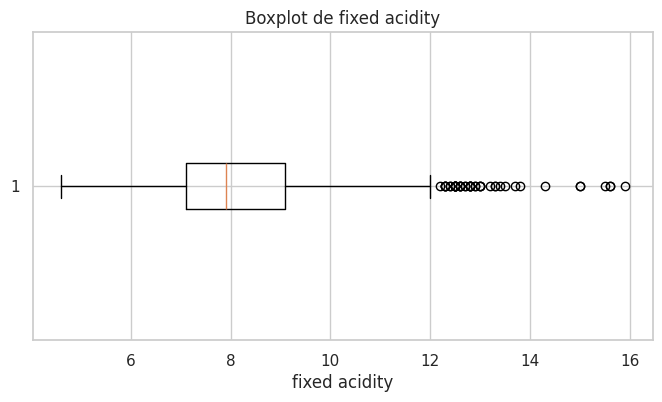

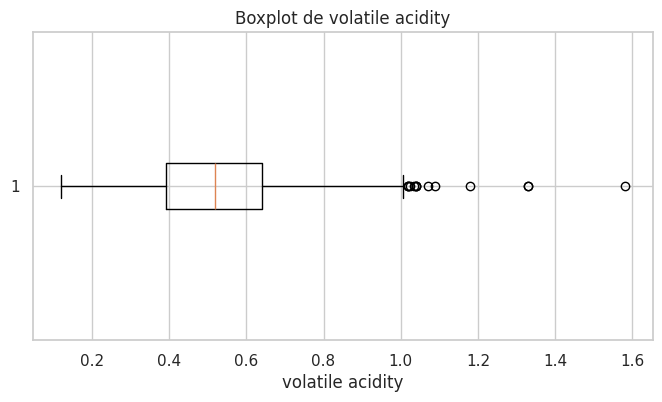

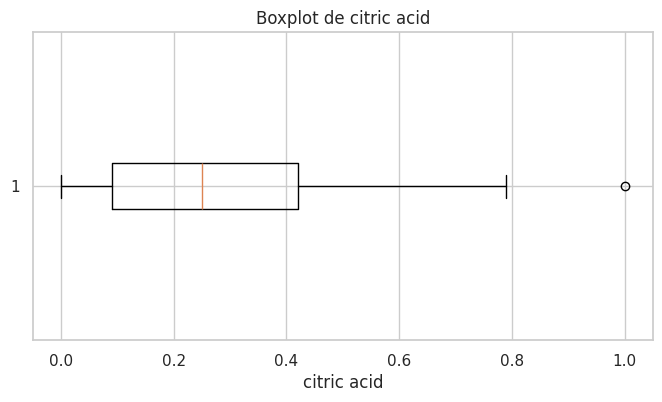

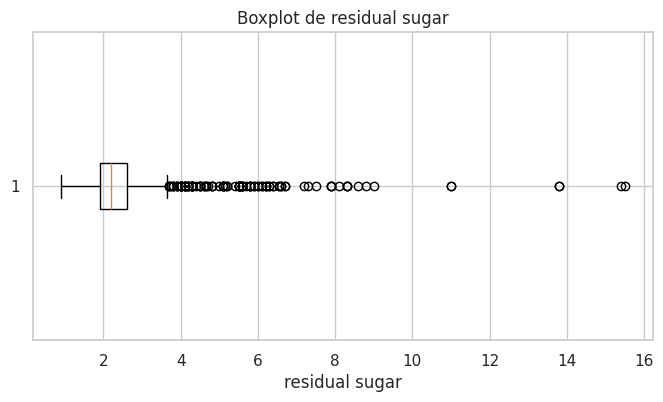

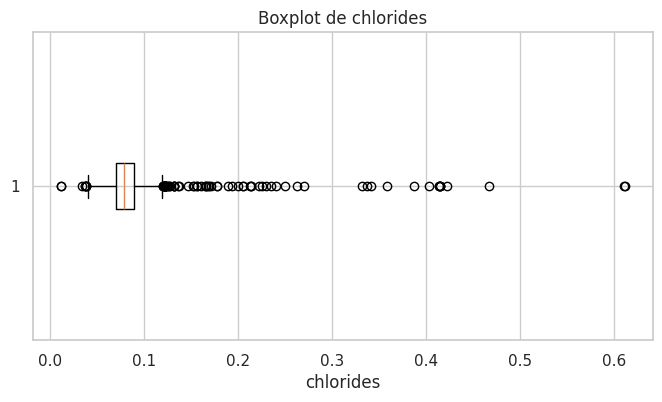

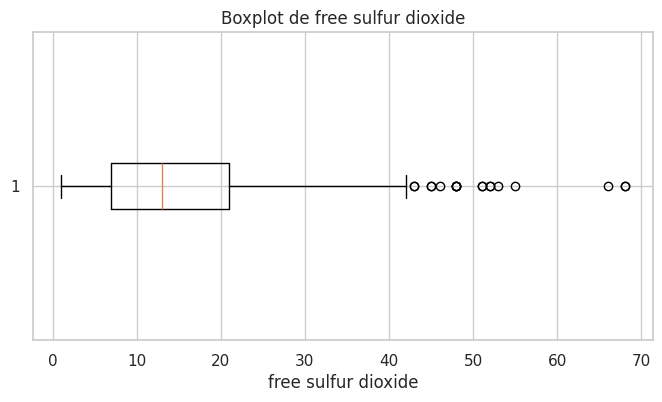

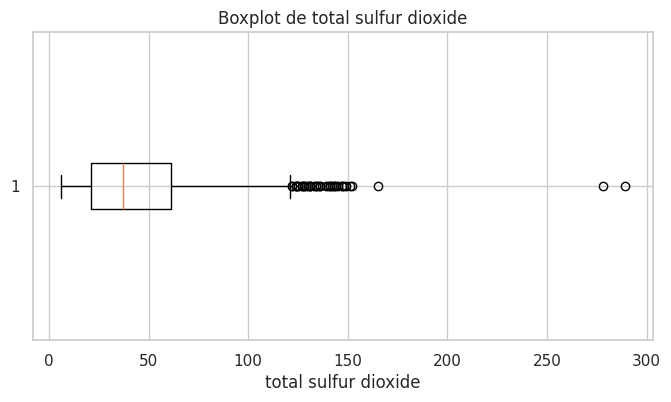

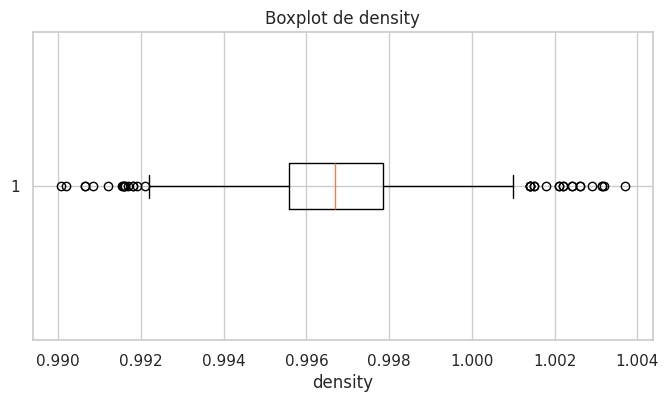

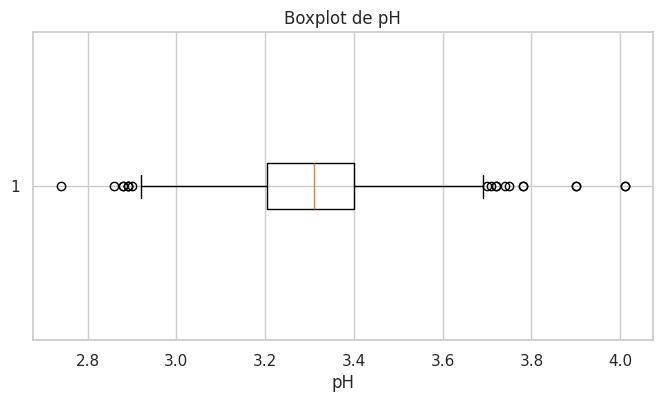

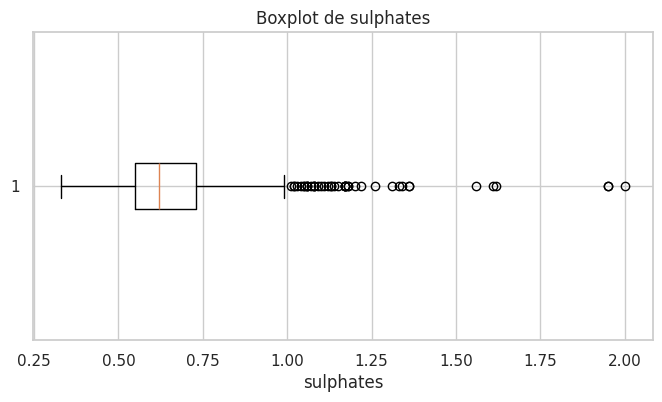

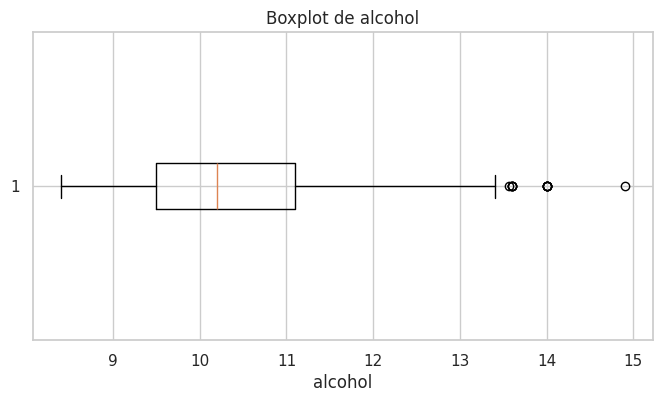

In [12]:
# Identificar outliers con boxplots

for col in variables:

    plt.figure(figsize=(8,4))

    plt.boxplot(
        df[col],
        vert=False
    )

    plt.title(f'Boxplot de {col}')
    plt.xlabel(col)

    plt.show()

In [13]:
# Revisar outliers usando método IQR

for col in variables:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    outliers = df[
        (df[col] < limite_inferior) |
        (df[col] > limite_superior)
    ]

    print(f'{col}: {len(outliers)} outliers')

fixed acidity: 44 outliers
volatile acidity: 14 outliers
citric acid: 1 outliers
residual sugar: 110 outliers
chlorides: 77 outliers
free sulfur dioxide: 18 outliers
total sulfur dioxide: 40 outliers
density: 36 outliers
pH: 20 outliers
sulphates: 43 outliers
alcohol: 12 outliers


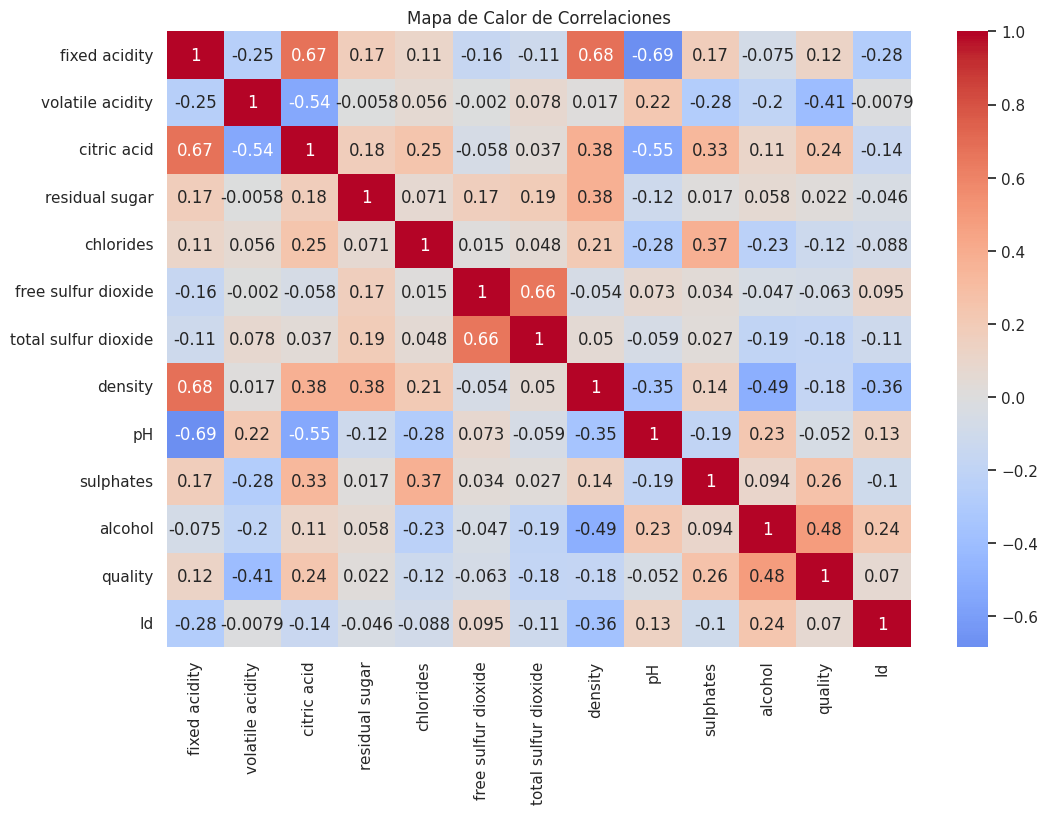

In [14]:
# Mapa de calor de correlaciones

correlation_matrix = df.corr(method='pearson')

plt.figure(figsize=(12,8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    center=0
)

plt.title('Mapa de Calor de Correlaciones')

plt.show()

In [15]:
# Correlación de variables con quality

print(df.corr(method='pearson')['quality'].sort_values(ascending=False))

quality                 1.000000
alcohol                 0.484866
sulphates               0.257710
citric acid             0.240821
fixed acidity           0.121970
Id                      0.069708
residual sugar          0.022002
pH                     -0.052453
free sulfur dioxide    -0.063260
chlorides              -0.124085
density                -0.175208
total sulfur dioxide   -0.183339
volatile acidity       -0.407394
Name: quality, dtype: float64


El análisis exploratorio muestra que la variable objetivo quality se concentra principalmente en las categorías 5 y 6, representando más del 80% de las observaciones, mientras que las calidades extremas (3, 4 y 8) son poco frecuentes. El dataset no presenta valores nulos ni registros duplicados, lo que facilita el proceso de modelado. Sin embargo, se identificaron outliers en varias variables, especialmente en residual sugar, chlorides, fixed acidity y sulphates, los cuales deberán evaluarse antes del entrenamiento de los modelos. Respecto a las correlaciones, alcohol presenta la relación positiva más fuerte con la calidad (0.48), seguido de sulphates (0.26) y citric acid (0.24), mientras que volatile acidity muestra la correlación negativa más importante (-0.41). Estos resultados sugieren que el contenido de alcohol y la acidez volátil serán variables relevantes para la predicción de la calidad del vino

**2. Preprocesamiento de Datos:**

2.1. Seleccionar características importantes para la clasificación.

2.2. Transformar variables categóricas en variables numéricas si es necesario.

2.3. Dividir los datos en conjuntos de entrenamiento y prueba.

2.4. Escalar las características.

In [16]:
# 2.1. Seleccionar características importantes para la clasificación.
corr_quality = df.corr(numeric_only=True)['quality'].sort_values(ascending=False)

print(corr_quality)

quality                 1.000000
alcohol                 0.484866
sulphates               0.257710
citric acid             0.240821
fixed acidity           0.121970
Id                      0.069708
residual sugar          0.022002
pH                     -0.052453
free sulfur dioxide    -0.063260
chlorides              -0.124085
density                -0.175208
total sulfur dioxide   -0.183339
volatile acidity       -0.407394
Name: quality, dtype: float64


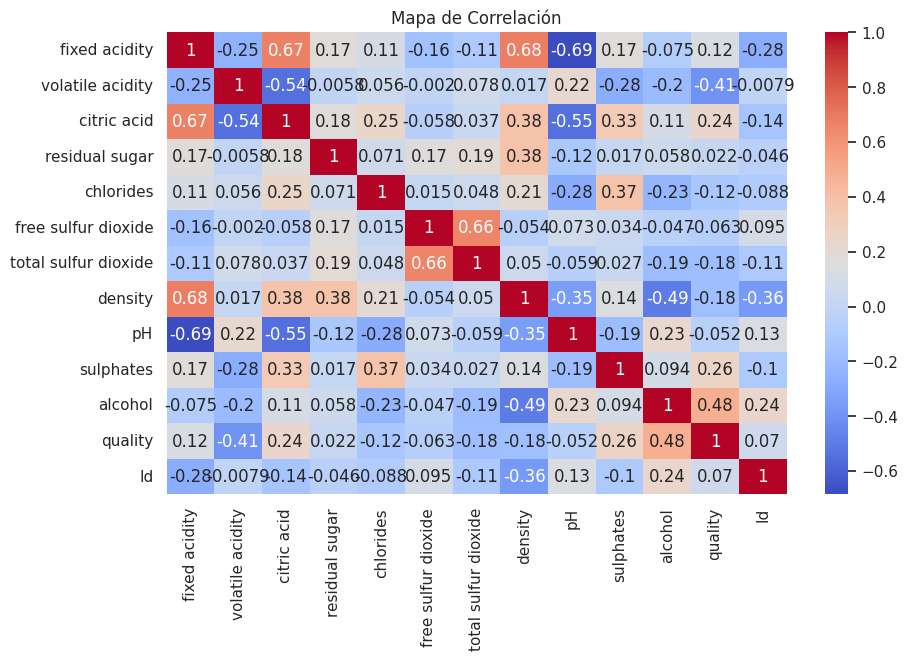

In [17]:
plt.figure(figsize=(10,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.title('Mapa de Correlación')
plt.show()

In [18]:
# 2.2. Transformar variables categóricas en variables numéricas si es necesario.
print(df.select_dtypes(include='object').columns)

Index([], dtype='object')


In [19]:
# 2.3. Dividir los datos en conjuntos de entrenamiento y prueba.
from sklearn.model_selection import train_test_split

X = df.drop(columns=['quality','Id'])
y = df['quality']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print('X_train:', X_train.shape)
print('X_test:', X_test.shape)
print('y_train:', y_train.shape)
print('y_test:', y_test.shape)

X_train: (914, 11)
X_test: (229, 11)
y_train: (914,)
y_test: (229,)


In [20]:
# 2.4. Escalar las características.
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [21]:
print(X_train_scaled.shape)
print(X_test_scaled.shape)

(914, 11)
(229, 11)


A partir de la matriz de correlación se identifica que alcohol es la variable con mayor capacidad explicativa respecto a la calidad del vino, seguida por sulphates y citric acid. En contraste, volatile acidity muestra una relación inversa importante con la calidad. La ausencia de correlaciones muy fuertes sugiere que el problema de clasificación requerirá considerar simultáneamente múltiples variables para lograr una predicción adecuada de la calidad del vino. Además, la variable Id presenta una correlación prácticamente nula con la calidad, por lo que puede eliminarse del proceso de modelado sin pérdida de información relevante.

**3. Entrenamiento de Modelos de Clasificación:**

3.1. Entrenar al menos tres modelos de clasificación diferentes (por ejemplo, KNN, RandomForest, y Regresión Logística).

3.2. Utilizar validación cruzada para seleccionar los mejores hiperparámetros.


In [22]:
# 3.1. Regresión Logística
from sklearn.linear_model import LogisticRegression

modelo_lr = LogisticRegression(
    max_iter=1000,
    random_state=42
)

modelo_lr.fit(
    X_train_scaled,
    y_train
)

print("Modelo entrenado correctamente")

Modelo entrenado correctamente


In [23]:
y_pred_lr = modelo_lr.predict(X_test_scaled)

In [24]:
from sklearn.neighbors import KNeighborsClassifier

# 3.1. K-Nearest Neighbors (KNN)

modelo_knn = KNeighborsClassifier(n_neighbors=5)
modelo_knn.fit(X_train_scaled,y_train)

print("Modelo entrenado correctamente")

Modelo entrenado correctamente


In [25]:
y_pred_knn = modelo_knn.predict(X_test_scaled)

In [26]:
from sklearn.ensemble import RandomForestClassifier

# 3.1. Random Forest
modelo_rf = RandomForestClassifier(n_estimators=100,random_state=42)
modelo_rf.fit(X_train,y_train)

print("Modelo entrenado correctamente")

Modelo entrenado correctamente


In [27]:
y_pred_rf = modelo_rf.predict(X_test)

In [28]:
# 3.2. Validación Cruzada para KNN
from sklearn.model_selection import cross_val_score

resultados_knn = []

for k in range(1,21):

    modelo = KNeighborsClassifier(
        n_neighbors=k
    )

    scores = cross_val_score(
        modelo,
        X_train_scaled,
        y_train,
        cv=5,
        scoring='accuracy'
    )

    resultados_knn.append(
        [k, scores.mean()]
    )

resultados_knn = pd.DataFrame(resultados_knn,columns=['K','Accuracy'])

display(resultados_knn)

,K,Accuracy
0,1,0.573230
1,2,0.543722
2,3,0.525137
3,4,0.528415
4,5,0.544809
5,6,0.573218
6,7,0.546977
7,8,0.557905
8,9,0.538215
9,10,0.548081


In [29]:
mejor_k = resultados_knn.loc[resultados_knn['Accuracy'].idxmax(),'K']

print("Mejor K:", mejor_k)

Mejor K: 19


In [30]:
modelo_knn = KNeighborsClassifier(n_neighbors=int(mejor_k))
modelo_knn.fit(X_train_scaled,y_train)
y_pred_knn = modelo_knn.predict(X_test_scaled)

In [31]:
scores_lr = cross_val_score(LogisticRegression(max_iter=1000,random_state=42),X_train_scaled,y_train,cv=5,scoring='accuracy')

print("Accuracy Promedio:",scores_lr.mean())

Accuracy Promedio: 0.5918513180808262


In [32]:
scores_rf = cross_val_score(RandomForestClassifier(n_estimators=100,random_state=42),X_train,y_train,cv=5,scoring='accuracy')

print("Accuracy Promedio:",scores_rf.mean())

Accuracy Promedio: 0.6465321563682218


In [33]:
# Comparación de modelos
resultados = pd.DataFrame({

    'Modelo':[
        'Regresión Logística',
        'KNN',
        'Random Forest'
    ],

    'Accuracy CV':[

        scores_lr.mean(),

        resultados_knn['Accuracy'].max(),

        scores_rf.mean()
    ]
})

resultados = resultados.sort_values(by='Accuracy CV',ascending=False)

display(resultados)

,Modelo,Accuracy CV
2,Random Forest,0.646532
0,Regresión Logística,0.591851
1,KNN,0.576509


Los resultados muestran que Random Forest fue el modelo con mejor capacidad predictiva, alcanzando una precisión promedio de 64,65%. La Regresión Logística obtuvo un desempeño intermedio (59,19%), mientras que KNN presentó el menor rendimiento (57,65%) incluso después de optimizar el valor de K mediante validación cruzada. Por lo tanto, Random Forest se perfila como el modelo más adecuado para continuar con la predicción de la calidad del vino.

**4. Evaluación de Modelos:**

4.1. Evaluar los modelos utilizando métricas como exactitud, precisión, recall, F1-Score y matriz de confusión.

4.2. Generar un informe de clasificación para cada modelo.

4.3. Crear y visualizar la curva ROC y calcular el AUC para el mejor modelo.


In [34]:
# 4.1. Evaluar los modelos
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,confusion_matrix)

In [38]:
print("REGRESIÓN LOGÍSTICA")
print("Accuracy:",accuracy_score(y_test,y_pred_lr))
print("Precision:",precision_score(y_test,y_pred_lr,average='weighted'))
print("Recall:",recall_score(y_test,y_pred_lr,average='weighted'))
print("F1-Score:",f1_score(y_test,y_pred_lr,average='weighted'))

REGRESIÓN LOGÍSTICA
Accuracy: 0.62882096069869
Precision: 0.6062207854970613
Recall: 0.62882096069869
F1-Score: 0.6169033158187924


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [37]:
print("KNN")
print("Accuracy:",accuracy_score(y_test,y_pred_knn))
print("Precision:",precision_score(y_test,y_pred_knn,average='weighted'))
print("Recall:",recall_score(y_test,y_pred_knn,average='weighted'))
print("F1-Score:",f1_score(y_test,y_pred_knn,average='weighted'))

KNN
Accuracy: 0.6069868995633187
Precision: 0.5740403593180324
Recall: 0.6069868995633187
F1-Score: 0.5880739846532104


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [39]:
print("RANDOM FOREST")
print("Accuracy:",accuracy_score(y_test,y_pred_rf))
print("Precision:",precision_score(y_test,y_pred_rf,average='weighted'))
print("Recall:",recall_score(y_test,y_pred_rf,average='weighted'))
print("F1-Score:",f1_score(y_test,y_pred_rf,average='weighted'))

RANDOM FOREST
Accuracy: 0.7030567685589519
Precision: 0.6775761436323177
Recall: 0.7030567685589519
F1-Score: 0.6893187631926734


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


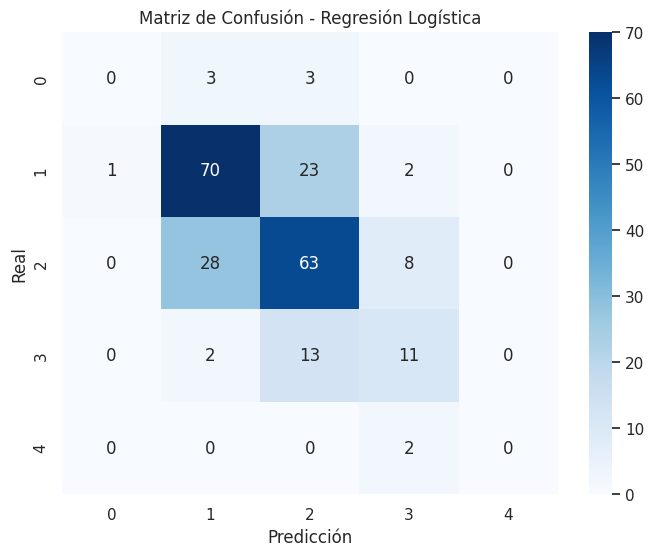

In [40]:
# Matriz de Confusión
# Regresión Logística

cm_lr = confusion_matrix(y_test,y_pred_lr)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm_lr,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Matriz de Confusión - Regresión Logística')
plt.xlabel('Predicción')
plt.ylabel('Real')

plt.show()


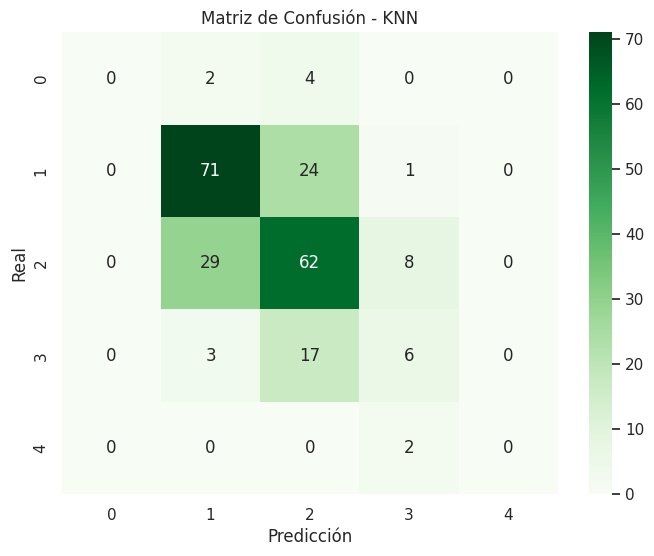

In [41]:
# KNN
cm_knn = confusion_matrix(y_test,y_pred_knn)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm_knn,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.title('Matriz de Confusión - KNN')
plt.xlabel('Predicción')
plt.ylabel('Real')

plt.show()

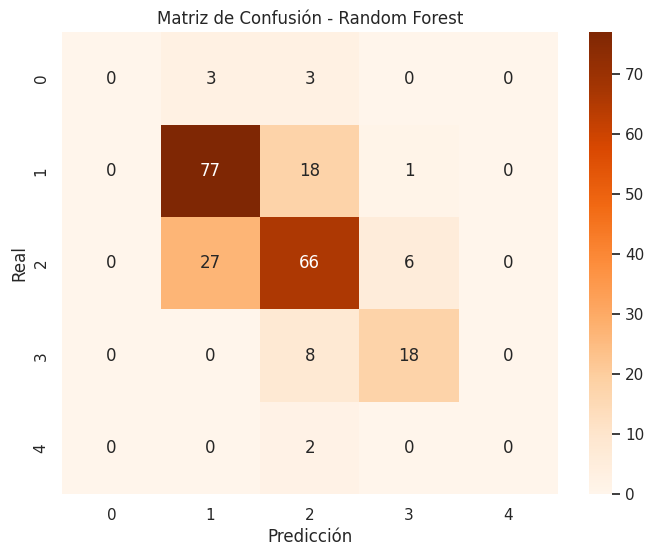

In [42]:
# Random Forest
cm_rf = confusion_matrix(y_test,y_pred_rf)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt='d',
    cmap='Oranges'
)

plt.title('Matriz de Confusión - Random Forest')
plt.xlabel('Predicción')
plt.ylabel('Real')

plt.show()

In [43]:
# 4.2. Informe de Clasificación
from sklearn.metrics import classification_report

print("REGRESIÓN LOGÍSTICA")
print(classification_report(y_test,y_pred_lr))

REGRESIÓN LOGÍSTICA
              precision    recall  f1-score   support

           4       0.00      0.00      0.00         6
           5       0.68      0.73      0.70        96
           6       0.62      0.64      0.63        99
           7       0.48      0.42      0.45        26
           8       0.00      0.00      0.00         2

    accuracy                           0.63       229
   macro avg       0.36      0.36      0.36       229
weighted avg       0.61      0.63      0.62       229



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [44]:
print("KNN")
print(classification_report(y_test,y_pred_knn))

KNN
              precision    recall  f1-score   support

           4       0.00      0.00      0.00         6
           5       0.68      0.74      0.71        96
           6       0.58      0.63      0.60        99
           7       0.35      0.23      0.28        26
           8       0.00      0.00      0.00         2

    accuracy                           0.61       229
   macro avg       0.32      0.32      0.32       229
weighted avg       0.57      0.61      0.59       229



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [45]:
print("RANDOM FOREST")
print(classification_report(y_test,y_pred_rf))

RANDOM FOREST
              precision    recall  f1-score   support

           4       0.00      0.00      0.00         6
           5       0.72      0.80      0.76        96
           6       0.68      0.67      0.67        99
           7       0.72      0.69      0.71        26
           8       0.00      0.00      0.00         2

    accuracy                           0.70       229
   macro avg       0.42      0.43      0.43       229
weighted avg       0.68      0.70      0.69       229



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [73]:
# 4.3. Curva ROC y AUC
df['quality_binary'] = np.where(df['quality'] >= 6,1,0)

X = df.drop(columns=['quality', 'quality_binary', 'Id'])
y = df['quality_binary']

In [76]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [77]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

modelo_lr = LogisticRegression(max_iter=1000, random_state=42)
modelo_lr.fit(X_train_scaled, y_train)
y_pred_lr = modelo_lr.predict(X_test_scaled)

modelo_knn = KNeighborsClassifier(n_neighbors=19)
modelo_knn.fit(X_train_scaled, y_train)
y_pred_knn = modelo_knn.predict(X_test_scaled)

modelo_rf = RandomForestClassifier(random_state=42)
modelo_rf.fit(X_train, y_train)
y_pred_rf = modelo_rf.predict(X_test)

In [82]:
from sklearn.ensemble import RandomForestClassifier

modelo_rf = RandomForestClassifier(n_estimators=100,random_state=42)
modelo_rf.fit(X_train,y_train)

RandomForestClassifier(random_state=42)

In [83]:
from sklearn.metrics import roc_curve, roc_auc_score

y_prob_rf = modelo_rf.predict_proba(X_test)[:,1]
fpr, tpr, thresholds = roc_curve(y_test,y_prob_rf)
auc_rf = roc_auc_score(y_test,y_prob_rf)

print("AUC:", auc_rf)

AUC: 0.8859811641191909


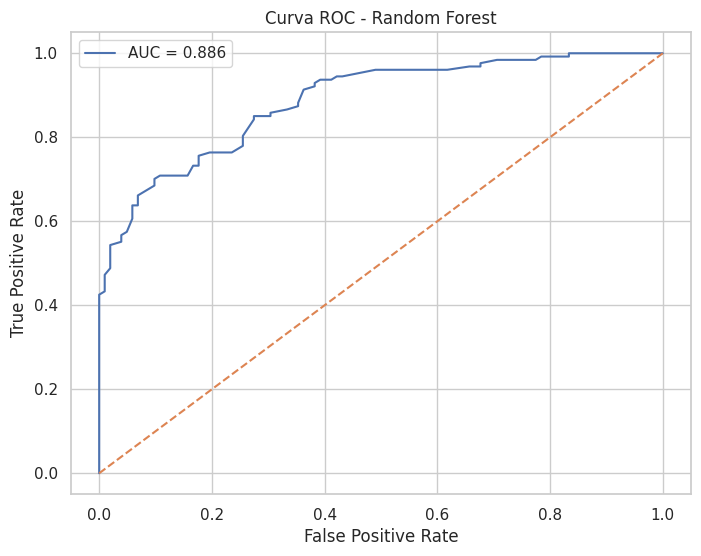

In [84]:
plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    label=f'AUC = {auc_rf:.3f}'
)

plt.plot(
    [0,1],
    [0,1],
    linestyle='--'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC - Random Forest')

plt.legend()

plt.show()

In [85]:
print(X.shape)
print(y.shape)

(1143, 11)
(1143,)


Se evaluaron tres modelos de clasificación para predecir la calidad del vino: Regresión Logística, KNN y Random Forest. Los resultados muestran que Random Forest obtuvo el mejor desempeño general, alcanzando una exactitud (Accuracy) de 70,31%, una precisión de 67,76%, un recall de 70,31% y un F1-Score de 68,93%, superando a Regresión Logística (62,88%) y KNN (60,70%). Además, las matrices de confusión muestran que Random Forest logró una mejor clasificación de las categorías de calidad más frecuentes (5, 6 y 7), cometiendo menos errores que los otros modelos.

El informe de clasificación evidencia que los tres modelos presentan dificultades para predecir las clases menos representadas, especialmente las calidades 4 y 8, donde la precisión y el recall son iguales a cero. Esto se debe al desbalance de clases observado durante el análisis exploratorio, ya que existen muy pocos ejemplos de estas categorías en comparación con las calidades 5 y 6. Por esta razón aparecen las advertencias (UndefinedMetricWarning), indicando que algunos modelos no realizaron predicciones para dichas clases.

Finalmente, la evaluación mediante la Curva ROC para el modelo Random Forest obtuvo un AUC = 0.886, lo que indica una excelente capacidad para diferenciar entre vinos de calidad baja y alta cuando el problema se transforma a clasificación binaria. La curva ROC se mantiene muy por encima de la línea aleatoria, confirmando que el modelo posee una capacidad predictiva sólida y consistente.

**5. Análisis y Comparación de Resultados:**

5.1. Comparar el rendimiento de los diferentes modelos.

5.2. Discutir cuál modelo ofrece el mejor rendimiento y por qué.

5.3. Identificar las fortalezas y debilidades de cada enfoque en este contexto.


In [89]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# 5.1. Comparar el rendimiento de los diferentes modelos
resultados = pd.DataFrame({
    'Modelo': [
        'Regresión Logística',
        'KNN',
        'Random Forest'
    ],
    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_knn),
        accuracy_score(y_test, y_pred_rf)
    ],
    'Precision': [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_knn),
        precision_score(y_test, y_pred_rf)
    ],
    'Recall': [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_knn),
        recall_score(y_test, y_pred_rf)
    ],
    'F1-Score': [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_knn),
        f1_score(y_test, y_pred_rf)
    ]
})

display(resultados)

,Modelo,Accuracy,Precision,Recall,F1-Score
0,Regresión Logística,0.768559,0.793651,0.787402,0.790514
1,KNN,0.751092,0.769231,0.787402,0.778210
2,Random Forest,0.764192,0.792000,0.779528,0.785714


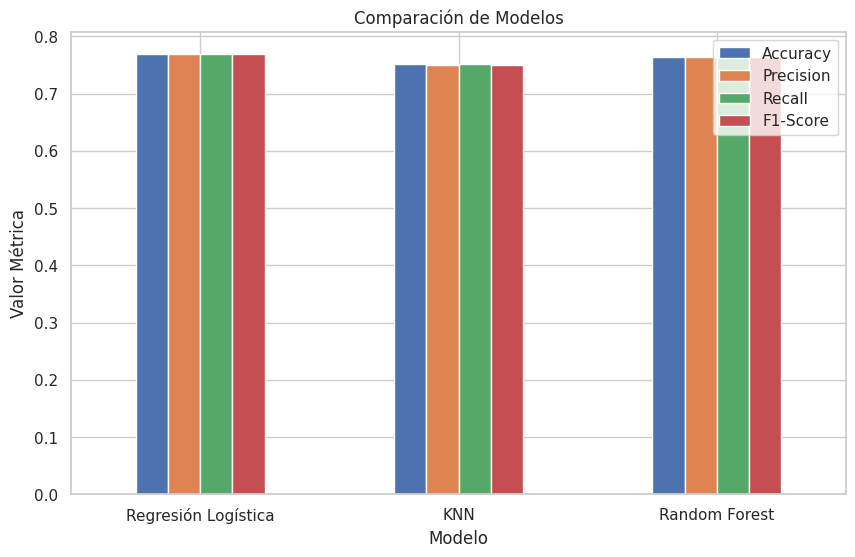

In [87]:
resultados.set_index('Modelo')[[
    'Accuracy',
    'Precision',
    'Recall',
    'F1-Score'
]].plot(
    kind='bar',
    figsize=(10,6)
)

plt.title('Comparación de Modelos')
plt.ylabel('Valor Métrica')
plt.xticks(rotation=0)

plt.show()

5.2. Discutir cuál modelo ofrece el mejor rendimiento y por qué.

Al transformar la variable quality en una clasificación binaria, los tres modelos obtuvieron resultados bastante similares. La Regresión Logística presentó el mejor desempeño general, con un Accuracy de 76,86% y el F1-Score más alto (79,05%), seguida muy de cerca por Random Forest, con un Accuracy de 76,42% y F1-Score de 78,57%. KNN obtuvo un rendimiento levemente inferior, con un Accuracy de 75,11%.

En este caso, la Regresión Logística se posiciona como el modelo más adecuado, ya que logra un buen equilibrio entre precisión y recall, además de ser más simple e interpretable. Esto sugiere que, al convertir la calidad del vino en dos categorías, las variables físico-químicas permiten separar razonablemente bien los vinos de calidad baja y alta.

5.3. Fortalezas y debilidades de cada enfoque.

Regresión Logística

Fortalezas

Fácil de interpretar.
Entrenamiento rápido.
Funciona bien cuando las relaciones son aproximadamente lineales.

Debilidades

Tiene dificultades para capturar relaciones complejas.
Menor desempeño que Random Forest.
No logró identificar adecuadamente las clases minoritarias.

KNN

Fortalezas

Algoritmo simple e intuitivo.
No requiere asumir una relación matemática específica entre variables.

Debilidades

Sensible al valor de K.
Requiere escalamiento de variables.
Menor capacidad de generalización en este dataset.
Fue el modelo con menor rendimiento global.

Random Forest

Fortalezas

Mejor Accuracy, Precision, Recall y F1-Score.
Maneja relaciones no lineales entre variables.
Menor sensibilidad a ruido y outliers.
Excelente capacidad predictiva (AUC = 0,886).

Debilidades

Menor interpretabilidad que Regresión Logística.
Mayor costo computacional.
Continúa teniendo dificultades con las clases muy poco representadas (calidades 4 y 8).